In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [10]:
df = pd.read_csv("ZBike_Rentals_Data.csv")
df.head()

,date,temperature_C,humidity_pct,wind_speed_kmh,season,weather,events,weekday,air_pressure_hpa,moon_phase,stock_index,tv_ad_spend,fuel_price,rental_count
0,1/1/2023,24.5,82.6,24.2,summer,clear,none,Sunday,1016.7,full,15183.7,1153.7,92.57,1111.0
1,1/2/2023,21.3,74.4,12.5,spring,rainy,none,Monday,1016.7,last_quarter,4685.9,4607.0,87.34,84.0
2,1/3/2023,25.2,71.8,10.7,summer,rainy,concert,Tuesday,1016.7,full,4802.1,2845.9,84.15,93.0
3,1/4/2023,29.6,72.1,22.4,summer,stormy,none,Wednesday,1016.7,full,5188.2,3548.8,75.64,24.0
4,1/5/2023,20.8,51.6,9.5,fall,clear,sports,Thursday,1016.7,first_quarter,4803.5,3637.4,89.86,30.0


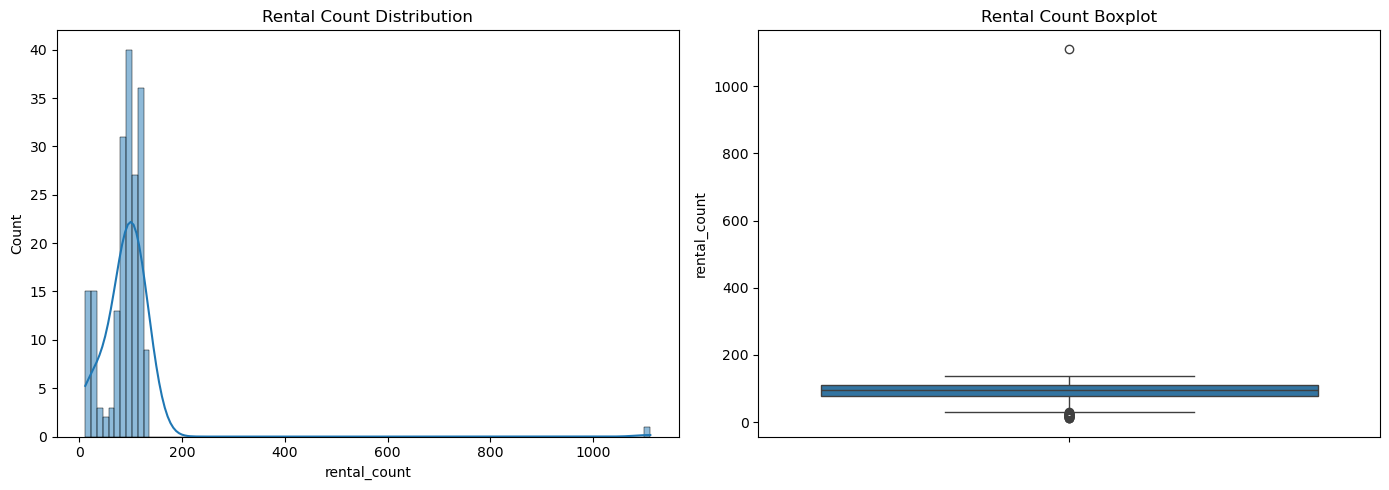

In [27]:
#1. Distribution Analysis
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df['rental_count'].dropna(),
    kde=True,
    ax=ax[0]
)
ax[0].set_title("Rental Count Distribution")

# Boxplot
sns.boxplot(
    y=df['rental_count'],
    ax=ax[1]
)
ax[1].set_title("Rental Count Boxplot")

plt.tight_layout()
plt.show()

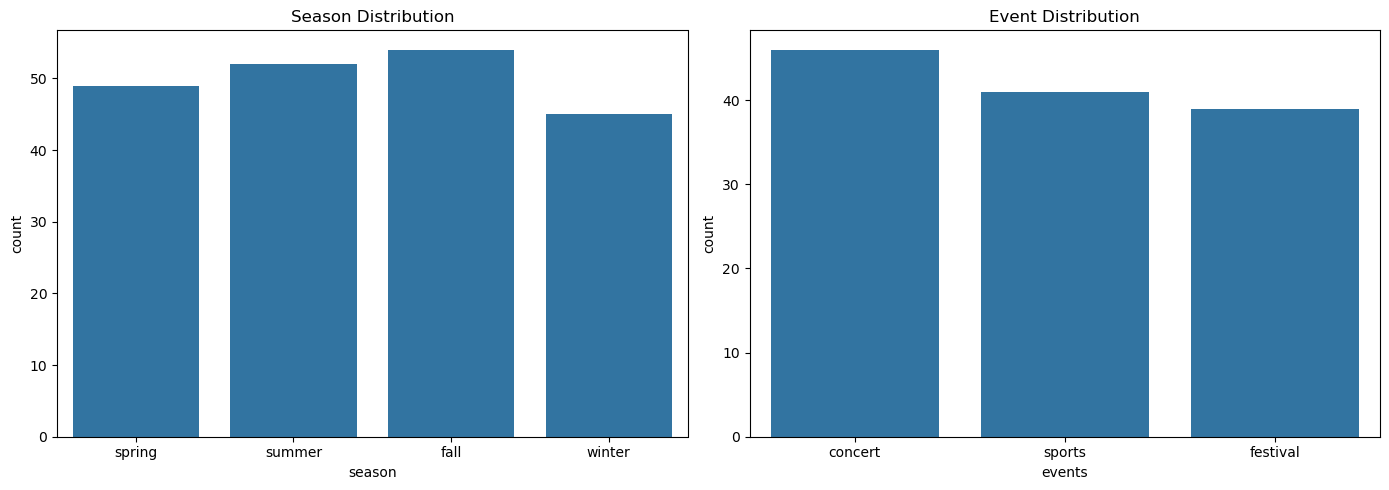

In [29]:
#2. Categorical Distributions
season_order = ['spring', 'summer', 'fall', 'winter']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x='season',
    order=season_order,
    ax=ax[0]
)
ax[0].set_title("Season Distribution")

event_df = df[df['events'] != 'none']

sns.countplot(
    data=event_df,
    x='events',
    ax=ax[1]
)
ax[1].set_title("Event Distribution")

plt.tight_layout()
plt.show()

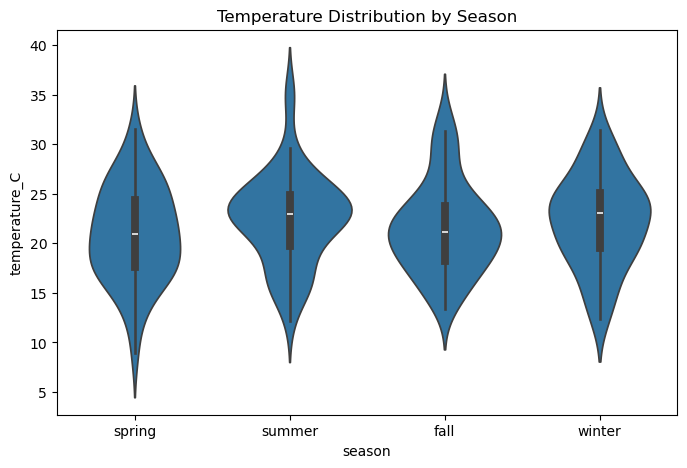

In [14]:
#3. Temperature Distribution by Season
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='season',
    y='temperature_C',
    order=['spring','summer','fall','winter']
)

plt.title("Temperature Distribution by Season")
plt.show()

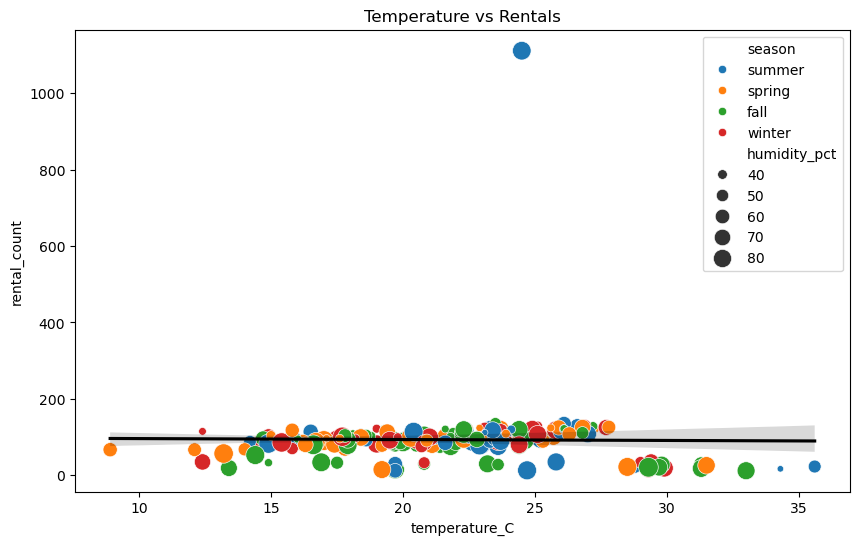

In [16]:
#4. Temperature vs Rentals
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='temperature_C',
    y='rental_count',
    hue='season',
    size='humidity_pct',
    sizes=(20,200)
)

sns.regplot(
    data=df,
    x='temperature_C',
    y='rental_count',
    scatter=False,
    color='black'
)

plt.title("Temperature vs Rentals")
plt.show()

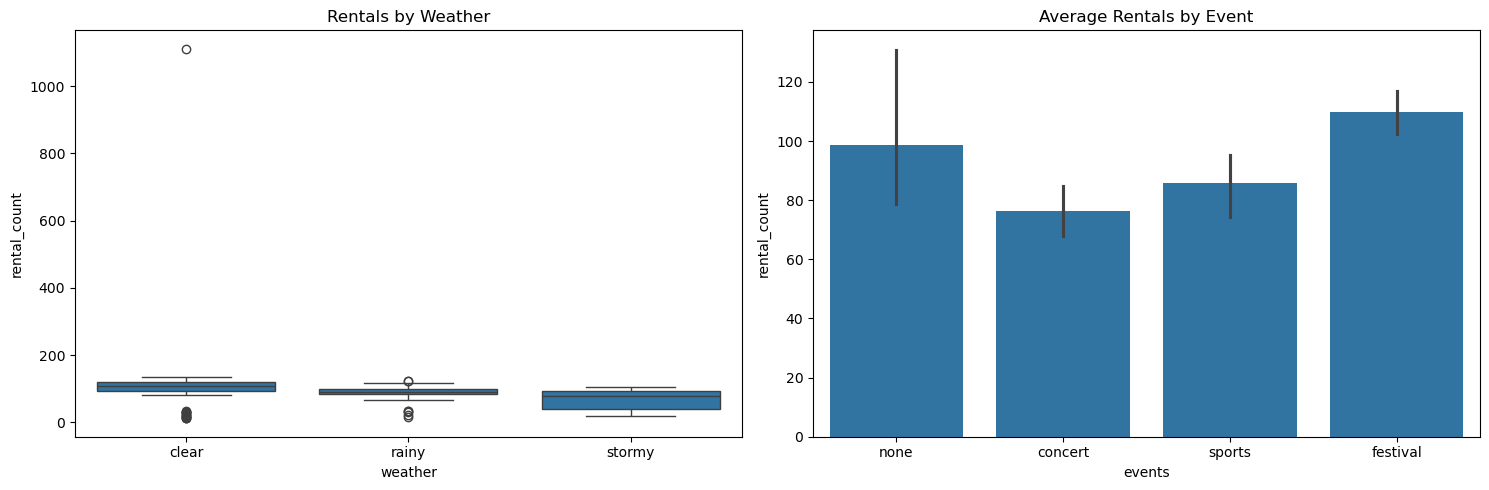

In [18]:
#5. Categorical Comparisons
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.boxplot(
    data=df,
    x='weather',
    y='rental_count',
    ax=ax[0]
)
ax[0].set_title("Rentals by Weather")

sns.barplot(
    data=df,
    x='events',
    y='rental_count',
    errorbar='ci',
    ax=ax[1]
)
ax[1].set_title("Average Rentals by Event")

plt.tight_layout()
plt.show()

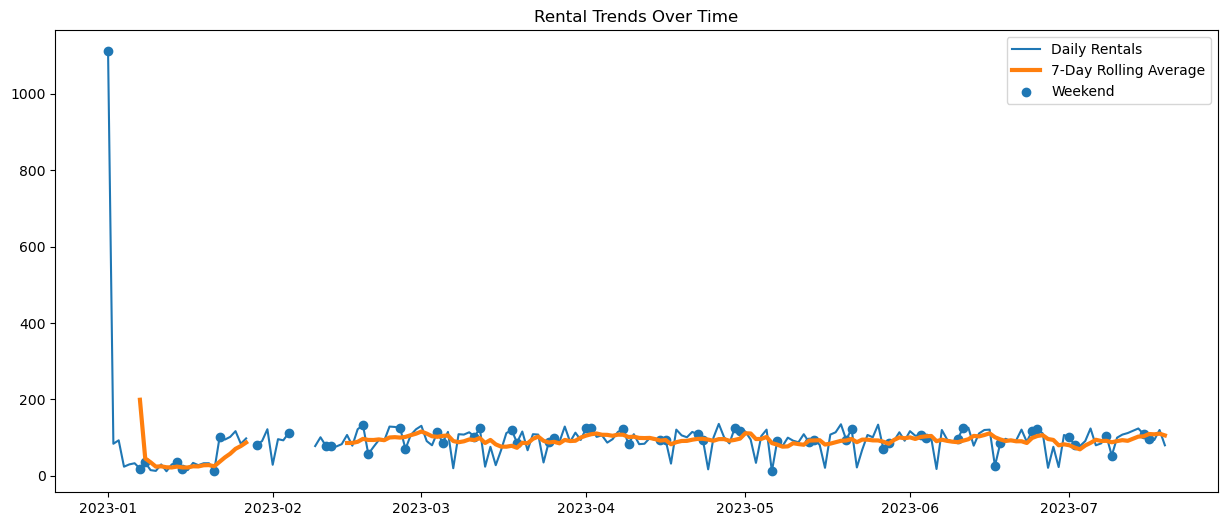

In [21]:
#6. Time Series Analysis
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

df['rolling_avg'] = df['rental_count'].rolling(7).mean()

plt.figure(figsize=(15,6))

plt.plot(
    df['date'],
    df['rental_count'],
    label='Daily Rentals'
)

plt.plot(
    df['date'],
    df['rolling_avg'],
    linewidth=3,
    label='7-Day Rolling Average'
)

weekends = df[
    df['date'].dt.dayofweek >= 5
]

plt.scatter(
    weekends['date'],
    weekends['rental_count'],
    label='Weekend'
)

plt.legend()
plt.title("Rental Trends Over Time")
plt.show()

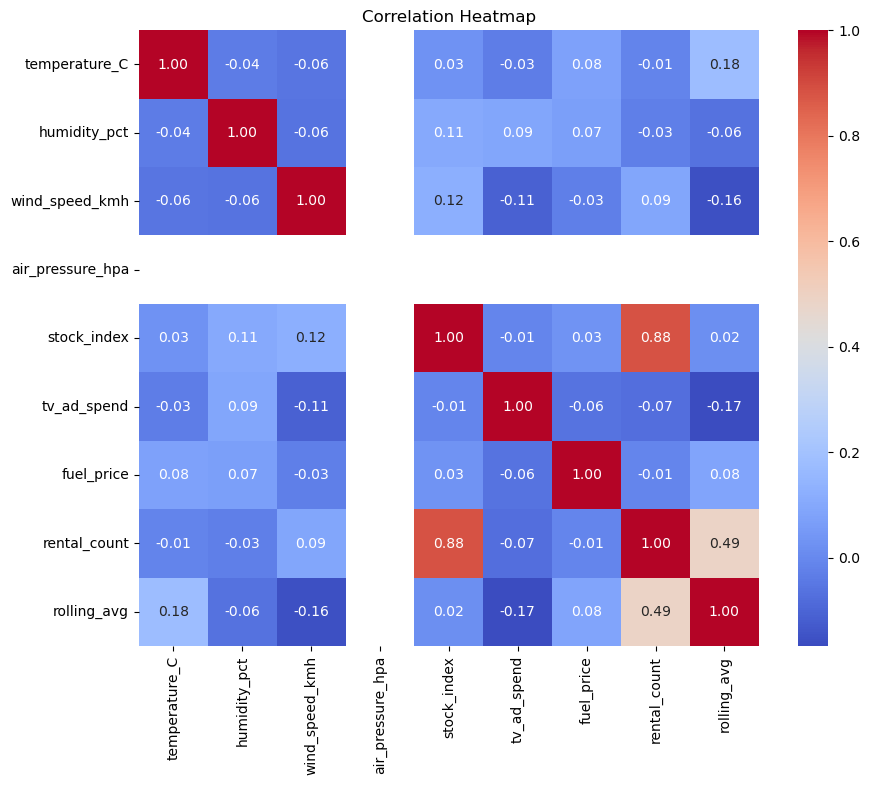

In [23]:
#7. Correlation Heatmap
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

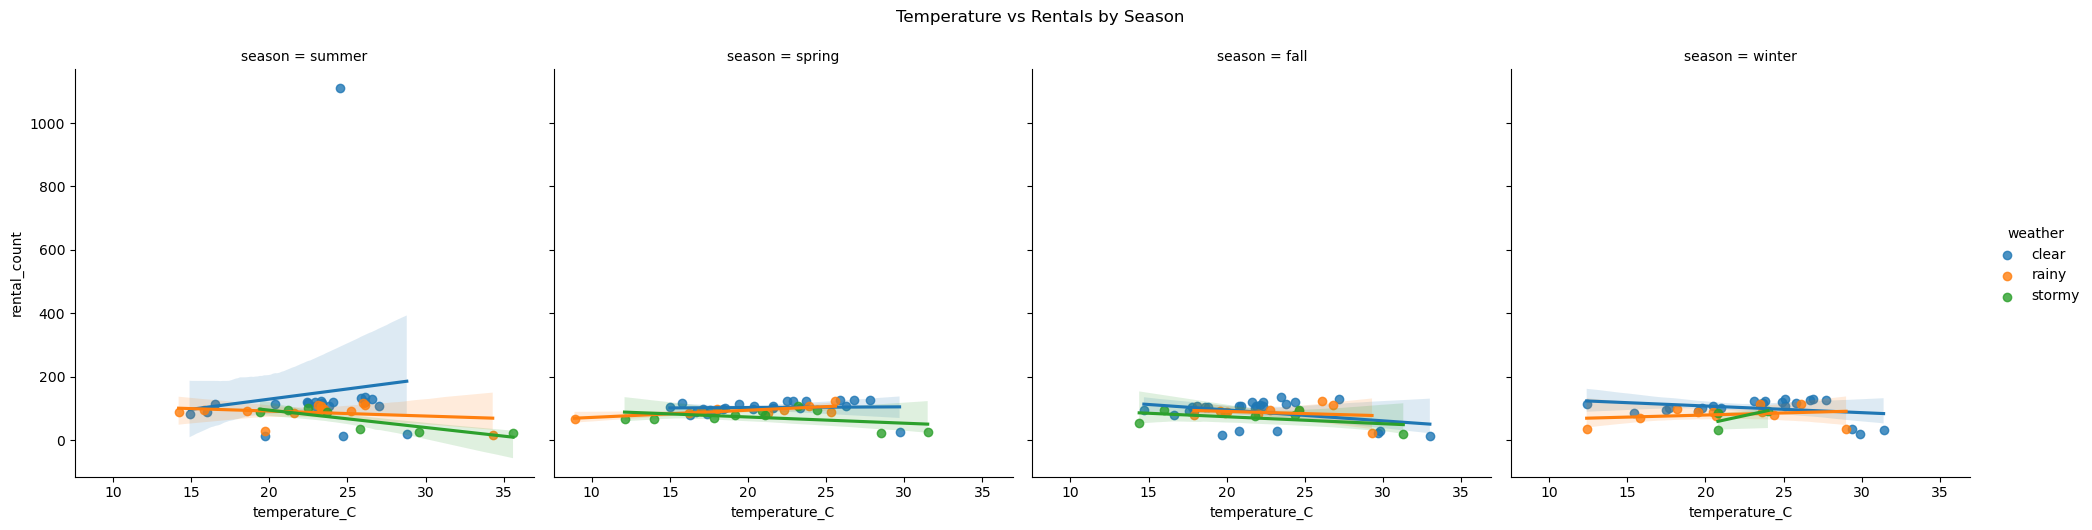

In [25]:
#8. Facet Grid Analysis
g = sns.lmplot(
    data=df,
    x='temperature_C',
    y='rental_count',
    col='season',
    hue='weather',
    height=5,
    aspect=1
)

g.fig.suptitle(
    "Temperature vs Rentals by Season",
    y=1.05
)

plt.show()